# Wyniki — System Rekomendacji NeuMF (MovieLens-1M)

Notebook do wizualizacji wyników końcowych:
- Krzywe loss (trening / walidacja)
- HitRate@10 i NDCG@10 vs baseline (popularność)
- Przykładowe rekomendacje dla wybranych użytkowników

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data.dataset import get_dataloaders, load_ratings, binarize, download_movielens
from models.ncf import NeuMF
from models.baseline import PopularityBaseline
from evaluate import evaluate_ranking, hit_rate_at_k, ndcg_at_k

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
train_loader, val_loader, test_loader, n_users, n_items, user_positives = get_dataloaders(
    batch_size=256, n_neg=0
)
print(f'Users: {n_users}, Items: {n_items}')

Users: 6040, Items: 3706


## 1. Załaduj wytrenowany model

In [3]:
model = NeuMF(n_users, n_items, gmf_dim=32, mlp_dim=32).to(device)
checkpoint_path = '../checkpoints/best_model.pt'

if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print('Checkpoint loaded.')
else:
    print(f'Checkpoint not found at {checkpoint_path}. Run train.py first.')

Checkpoint loaded.


## 2. Metryki NeuMF vs Popularity Baseline

In [4]:
# NeuMF ranking metrics
neumf_metrics = evaluate_ranking(model, test_loader, n_items, user_positives, device, k=10)
print('NeuMF:', neumf_metrics)

Evaluating (k=10):   0%|          | 0/195 [00:00<?, ?it/s]

Evaluating (k=10):   3%|▎         | 5/195 [00:00<00:03, 49.98it/s]

Evaluating (k=10):   6%|▌         | 12/195 [00:00<00:03, 52.30it/s]

Evaluating (k=10):   9%|▉         | 18/195 [00:00<00:03, 52.26it/s]

Evaluating (k=10):  12%|█▏        | 24/195 [00:00<00:03, 50.09it/s]

...

Evaluating (k=10):  92%|█████████▏| 180/195 [00:03<00:00, 42.27it/s]

Evaluating (k=10):  95%|█████████▌| 186/195 [00:04<00:00, 44.32it/s]

Evaluating (k=10):  98%|█████████▊| 192/195 [00:04<00:00, 45.00it/s]

Evaluating (k=10): 100%|██████████| 195/195 [00:04<00:00, 46.64it/s]

NeuMF: {'HitRate@10': 0.6596411774952099, 'NDCG@10': 0.378769886131241, 'n_users': 5741}


In [5]:
# Popularity baseline
from data.dataset import load_ratings, binarize, chronological_split

ratings, _, _ = load_ratings()
ratings = binarize(ratings)
train_df, val_df, test_df = chronological_split(ratings)

pop = PopularityBaseline(top_k=10).fit(train_df)

hit_rates, ndcgs = [], []
for _, row in test_df[test_df['label'] == 1].iterrows():
    u = int(row['user_id'])
    pos = int(row['movie_id'])
    exclude = user_positives.get(u, set()) - {pos}
    recs = pop.recommend(u, exclude=exclude, k=10)
    hit_rates.append(hit_rate_at_k(recs, {pos}))
    ndcgs.append(ndcg_at_k(recs, {pos}))

pop_metrics = {
    'HitRate@10': np.mean(hit_rates),
    'NDCG@10':    np.mean(ndcgs),
}
print('Popularity:', pop_metrics)

Popularity: {'HitRate@10': np.float64(0.04395406169202092), 'NDCG@10': np.float64(0.02154627716420559)}


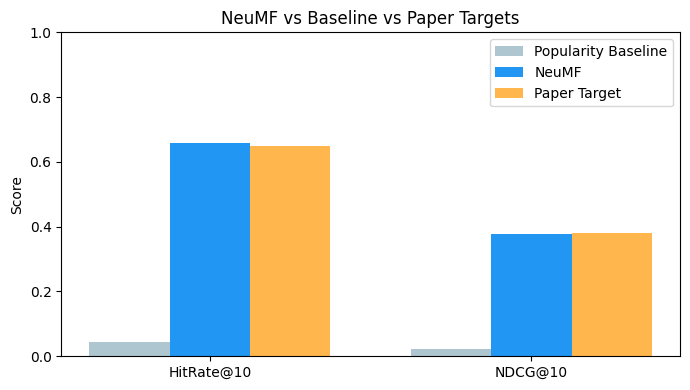


Poprawa HitRate@10 vs baseline: 1400.8%  (cel: >10%)


In [6]:
# Bar chart comparison
metrics_names = ['HitRate@10', 'NDCG@10']
neumf_vals = [neumf_metrics[m] for m in metrics_names]
pop_vals   = [pop_metrics[m]   for m in metrics_names]
targets    = [0.65, 0.38]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width, pop_vals,   width, label='Popularity Baseline', color='#aec6cf')
ax.bar(x,         neumf_vals, width, label='NeuMF',               color='#2196f3')
ax.bar(x + width, targets,    width, label='Paper Target',         color='#ff9800', alpha=0.7)

ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score'); ax.set_title('NeuMF vs Baseline vs Paper Targets')
ax.legend(); ax.set_ylim(0, 1.0); plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/metrics_comparison.png', dpi=150)
plt.show()

improvement_hr = (neumf_metrics['HitRate@10'] - pop_metrics['HitRate@10']) / pop_metrics['HitRate@10'] * 100
print(f'\nPoprawa HitRate@10 vs baseline: {improvement_hr:.1f}%  (cel: >10%)')

## 3. Przykładowe rekomendacje

In [7]:
# Load movie titles
data_dir = download_movielens()
movies = pd.read_csv(
    os.path.join(data_dir, 'movies.dat'),
    sep='::',
    engine='python',
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1',
)
movie_ids_sorted = sorted(load_ratings(data_dir)[0]['movie_id'].unique())
idx2title = {i: movies[movies['movie_id'] == mid]['title'].values[0]
             for i, mid in enumerate(movie_ids_sorted)
             if mid in movies['movie_id'].values}

print('Titles loaded.')

Titles loaded.


In [8]:
def show_recommendations(user_id: int, k: int = 10):
    all_items = torch.arange(n_items, dtype=torch.long, device=device)
    u_tensor  = torch.full((n_items,), user_id, dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        scores = model(u_tensor, all_items).cpu().numpy()

    # Mask known positives
    for idx in user_positives.get(user_id, set()):
        scores[idx] = -np.inf

    top_k = np.argsort(scores)[::-1][:k]
    print(f'\nTop-{k} rekomendacji dla użytkownika {user_id}:')
    for rank, item_idx in enumerate(top_k, 1):
        title = idx2title.get(item_idx, f'item_{item_idx}')
        print(f'  {rank:2d}. {title}  (score={scores[item_idx]:.3f})')

# Przykłady
show_recommendations(user_id=0)
show_recommendations(user_id=42)


Top-10 rekomendacji dla użytkownika 0:
   1. Loser (1991)  (score=0.989)
   2. Cobb (1994)  (score=0.981)
   3. Prerokbe Ognja (1995)  (score=0.977)
   4. Wings of Courage (1995)  (score=0.976)
   5. Children of Heaven, The (Bacheha-Ye Aseman) (1997)  (score=0.970)
   6. Red Firecracker, Green Firecracker (1994)  (score=0.963)
   7. Frankenstein Meets the Wolf Man (1943)  (score=0.962)
   8. Backbeat (1993)  (score=0.958)
   9. Leopard Son, The (1996)  (score=0.958)
  10. Scorta, La (1993)  (score=0.952)

Top-10 rekomendacji dla użytkownika 42:
   1. Next Friday (1999)  (score=0.963)
   2. Dry Cleaning (Nettoyage à sec) (1997)  (score=0.961)
   3. Naturally Native (1998)  (score=0.947)
   4. Fall (1997)  (score=0.937)
   5. American Werewolf in Paris, An (1997)  (score=0.935)
   6. Loss of Sexual Innocence, The (1999)  (score=0.928)
   7. Money Pit, The (1986)  (score=0.924)
   8. Payback (1999)  (score=0.923)
   9. Dear Diary (Caro Diario) (1994)  (score=0.916)
  10. Knockout (1999) 